In [ ]:
#load data into dataframes
from enum import Enum
import pandas as pd
import plotly.express as ptex
import matplotlib.pyplot as plt
from os import path
from glob import glob

class CenipaData(Enum):
    aeronave = r'https://raw.githubusercontent.com/fmariane/sprint1-mvp/main/datasources/CENIPA_FAB/aeronave.csv'
    fator_contribuicao = r'https://raw.githubusercontent.com/fmariane/sprint1-mvp/main/datasources/CENIPA_FAB/fator_contribuinte.csv'
    ocorrencia = r'https://raw.githubusercontent.com/fmariane/sprint1-mvp/main/datasources/CENIPA_FAB/ocorrencia.csv'
    tipo_de_ocorrencia = r'https://raw.githubusercontent.com/fmariane/sprint1-mvp/main/datasources/CENIPA_FAB/ocorrencia_tipo.csv'
    recomendacao_cenipa = r'https://raw.githubusercontent.com/fmariane/sprint1-mvp/main/datasources/CENIPA_FAB/recomendacao.csv'

def load_dataframe(url: str, sep: str = ";", encoding: str = "latin1") -> pd.DataFrame:
    return pd.read_csv(url, sep=sep, encoding=encoding)

df_aeronave = load_dataframe(CenipaData.aeronave.value)
df_fator_contribuicao = load_dataframe(CenipaData.fator_contribuicao.value)
df_tipo_de_ocorrencia = load_dataframe(CenipaData.tipo_de_ocorrencia.value)
df_ocorrencia = load_dataframe(CenipaData.ocorrencia.value)
df_recomendacao_cenipa = load_dataframe(CenipaData.recomendacao_cenipa.value)

Analise do conjunto de dados de "Ocorrencias". Na aviação, as ocorrências operacionais ou de segurança são classificadas em acidentes, incidentes graves e apenas incidentes. Os incidentes são aqueles em que a ocorrência afeta o funcionamente e compromete a segurança operacional, porém sem danos e sem feridos. Os incidentes graves envolvem uma falha séria de segurança, mas ainda sem a ocorrência de feridos. Os acidentes são ocorrências em que ocorre dano grave à aeronave e ou/feridos.
Portanto vamos observar primeiramente a diferença da taxa de acidentes e incidentes registrados no dataset ocorrencias

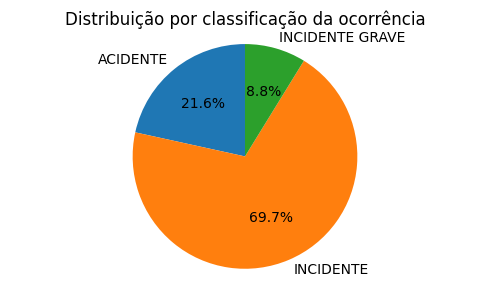

In [11]:
# Pie chart: distribuição por classificação (ACIDENTE, INCIDENTE, INCIDENTE GRAVE)
contagem = df_ocorrencia['ocorrencia_classificacao'].value_counts()
categorias = ['ACIDENTE', 'INCIDENTE', 'INCIDENTE GRAVE']
contagem_filtrada = contagem.reindex(categorias).fillna(0).astype(int)

plt.figure(figsize=(5, 3))
plt.pie(contagem_filtrada, labels=contagem_filtrada.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição por classificação da ocorrência')
plt.axis('equal')
plt.tight_layout()
plt.show()